In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load Data Files
train_df = pd.read_csv(r"C:/Users/daraa/Desktop/Transformer-based vs. Hybrid Deep Learning Architectures/Data/train.csv")
test_df = pd.read_csv(r"C:/Users/daraa/Desktop/Transformer-based vs. Hybrid Deep Learning Architectures/Data/test.csv")
print("Data files loaded Successfully")

Data files loaded Successfully


In [64]:
print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

train_df.head()
train_df.info()
train_df.describe()

Train Shape: (913000, 6)
Test Shape: (45000, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   date         913000 non-null  datetime64[ns]
 1   store        913000 non-null  int64         
 2   item         913000 non-null  int64         
 3   sales        913000 non-null  int64         
 4   day_of_week  913000 non-null  object        
 5   month        913000 non-null  int32         
dtypes: datetime64[ns](1), int32(1), int64(3), object(1)
memory usage: 38.3+ MB


,date,store,item,sales,month
count,913000,913000.000000,913000.000000,913000.000000,913000.000000
mean,2015-07-02 11:59:59.999999744,5.500000,25.500000,52.250287,6.523549
min,2013-01-01 00:00:00,1.000000,1.000000,0.000000,1.000000
25%,2014-04-02 00:00:00,3.000000,13.000000,30.000000,4.000000
50%,2015-07-02 12:00:00,5.500000,25.500000,47.000000,7.000000
75%,2016-10-01 00:00:00,8.000000,38.000000,70.000000,10.000000
max,2017-12-31 00:00:00,10.000000,50.000000,231.000000,12.000000
std,NaN,2.872283,14.430878,28.801144,3.448535


Explanation:
This step inspects the dataset structure to understand the number of records, columns, and data types.
Understanding dataset structure helps verify whether the data was loaded correctly and ensures the features required for forecasting are present.

In [65]:
# Convert date column to datetime format
train_df['date'] = pd.to_datetime(train_df['date'])
test_df['date'] = pd.to_datetime(test_df['date'])

# Verify datatype
print(train_df.dtypes)

date           datetime64[ns]
store                   int64
item                    int64
sales                   int64
day_of_week            object
month                   int32
dtype: object


Explanation:
The date column is initially stored as text. For time-series analysis, it must be converted into a datetime format so Python can perform time-based operations like extracting month, weekday, or year.

In [31]:
train_df.isnull().sum()

date     0
store    0
item     0
sales    0
dtype: int64

Explanation:
Missing values can cause issues during model training or feature engineering. Therefore, it is important to check whether the dataset contains any missing observations.

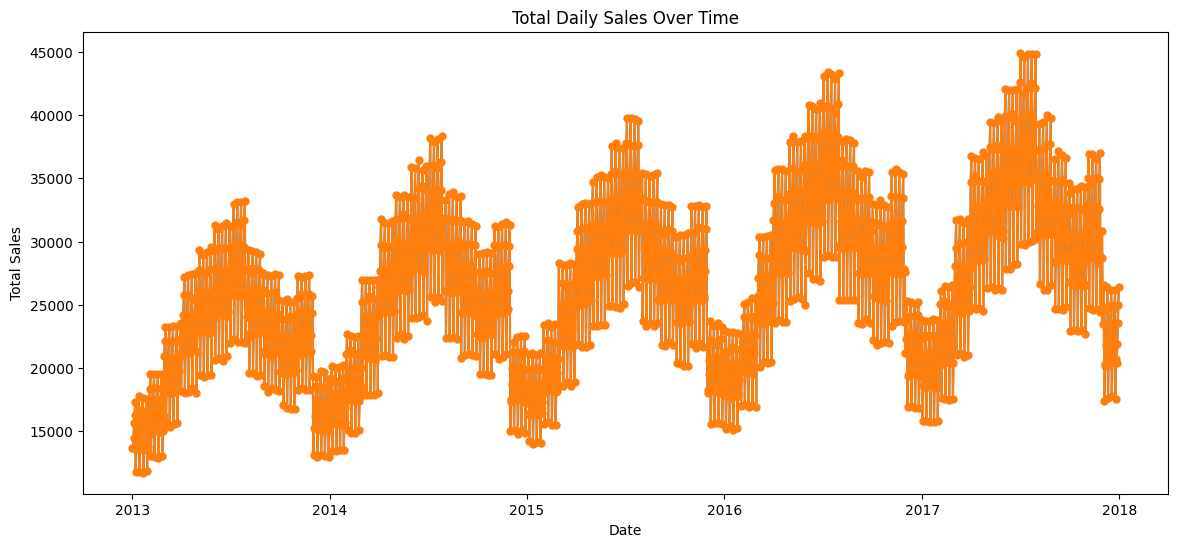

In [35]:
# Aggregate total sales per day
daily_sales = train_df.groupby('date')['sales'].sum()

# Plot sales trend
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(daily_sales)
plt.plot(daily_sales, marker = 'o', markersize = 5)

plt.title("Total Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.show()

Explanation:
This visualization shows how total sales change over time.
It helps detect long-term trends and repeating seasonal patterns.

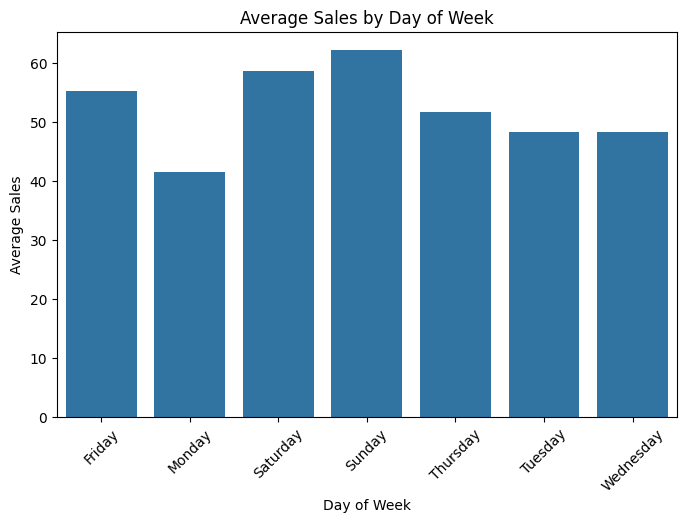

In [56]:
# Create weekday feature
train_df['day_of_week'] = train_df['date'].dt.day_name()

# Average sales per weekday
weekly_sales = train_df.groupby('day_of_week')['sales'].mean()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(x=weekly_sales.index, y=weekly_sales.values)

plt.title("Average Sales by Day of Week"),
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")

plt.xticks(rotation=45)
plt.show()

Explanation:
Retail demand often varies depending on the day of the week.
This analysis calculates the average sales for each weekday to detect weekly seasonality.

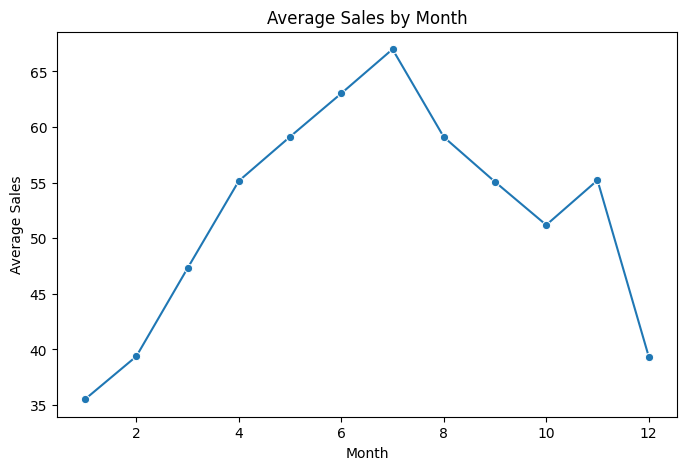

In [57]:
# Create month feature
train_df['month'] = train_df['date'].dt.month

# Average sales per month
monthly_sales = train_df.groupby('month')['sales'].mean()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker='o')

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.show()

Explanation:
This step investigates whether sales vary across different months of the year, which helps detect yearly seasonal demand cycles.

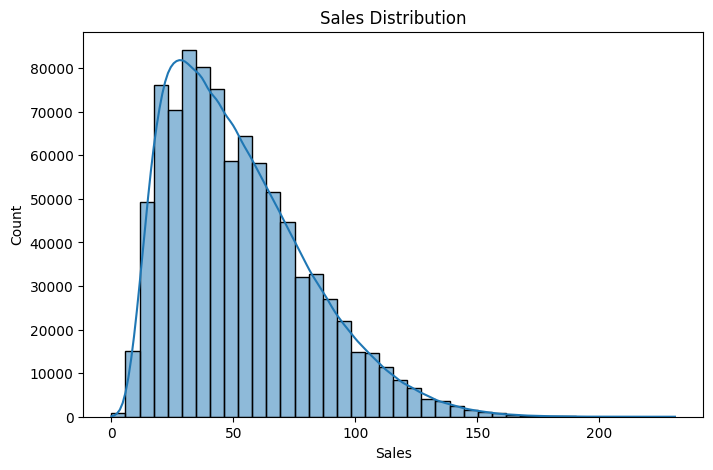

In [59]:
plt.figure(figsize=(8,5))
sns.histplot(train_df['sales'], bins=40, kde=True)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.show()

Explanation:
Understanding the distribution of the target variable (sales) helps determine whether the data is skewed or normally distributed.

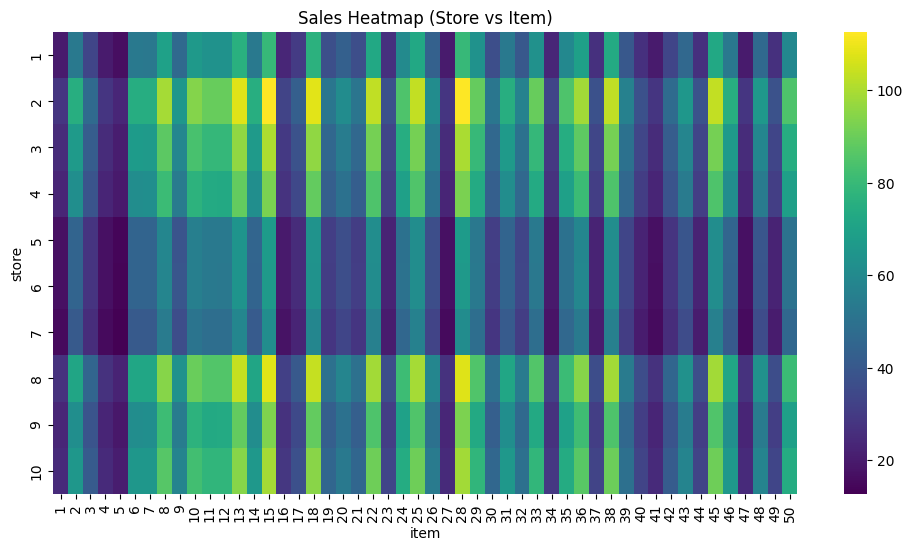

In [60]:
pivot_table = train_df.pivot_table(values='sales', index='store', columns='item')

plt.figure(figsize=(12,6))
sns.heatmap(pivot_table, cmap="viridis")
plt.title("Sales Heatmap (Store vs Item)")
plt.show()

Explanation:
This visualization helps understand how sales vary across stores and items.

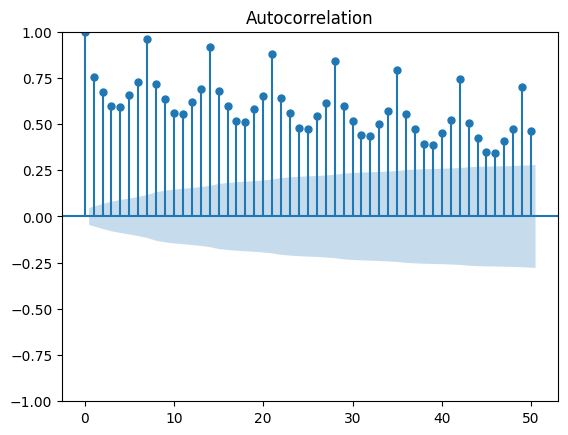

In [61]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(daily_sales, lags=50)
plt.show()

Explanation:
Autocorrelation measures how strongly current values depend on past observations.
This helps determine the importance of lag features in forecasting models.

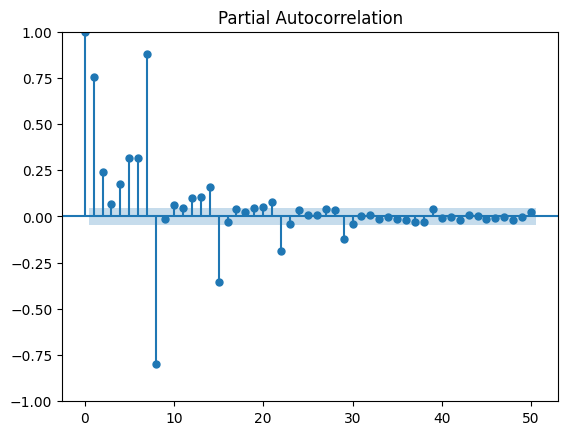

In [62]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(daily_sales, lags=50)
plt.show()

Explanation:
Autocorrelation measures how strongly current values depend on past observations.
This helps determine the importance of lag features in forecasting models.

In [63]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(daily_sales)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -3.060244118701348
p-value: 0.029638649268843572


Explanation:
Stationarity means the statistical properties of the time series (mean and variance) remain constant over time.
Many forecasting models require or benefit from stationary data.